### Define parameters for the SPC tool

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML


# Load the dataset
file_path = r'C:\Users\NidhinD\OneDrive - PBC Linear\Documents\nidhin.dev\Python Files\python.py\py.datasets\wine+quality\winequality-red.csv'

df = pd.read_csv(file_path, sep=';')
print(df.describe())

style = {
    'description_width': '150px',
    'width': '450px'
}

column_dropdown  = widgets.Dropdown(options=df.columns.tolist(), description='Select Column:', style=style)

chart_type_dropdown = widgets.Dropdown( options=['xbar_r', 'im_r', 'xbar_s'], description='Select Chart Type:', style=style )

subgroup_size_slider = widgets.IntSlider( value=5, min=2, max=25, step=1, description='Subgroup Size:', style=style)

usl_input = widgets.FloatText( value=3.45, description='USL:', style=style)
lsl_input = widgets.FloatText( value=3.15, description='LSL:', style=style)

def auto_select_chart(change):
    n = change['new']
    if n == 2:
        chart_type_dropdown.value = 'im_r'
    elif n < 10:
        chart_type_dropdown.value = 'xbar_r'
    else:
        chart_type_dropdown.value = 'xbar_s'

subgroup_size_slider.observe(auto_select_chart, names='value')

display(HTML("<h3>SPC Control Chart Generator</h3>"))
display(column_dropdown, chart_type_dropdown, subgroup_size_slider, usl_input, lsl_input)


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

Dropdown(description='Select Column:', options=('fixed acidity', 'volatile acidity', 'citric acid', 'residual …

Dropdown(description='Select Chart Type:', options=('xbar_r', 'im_r', 'xbar_s'), style=DescriptionStyle(descri…

IntSlider(value=5, description='Subgroup Size:', max=25, min=2, style=SliderStyle(description_width='150px'))

FloatText(value=3.45, description='USL:', style=DescriptionStyle(description_width='150px'))

FloatText(value=3.15, description='LSL:', style=DescriptionStyle(description_width='150px'))

### Read Values from Settings

In [19]:
column       = column_dropdown.value
chart_type   = chart_type_dropdown.value
subgroup_size = subgroup_size_slider.value
USL          = usl_input.value
LSL          = lsl_input.value
values       = df[column].values

print(f"Selected Column: {column}")
print(f"Selected Chart Type: {chart_type}")
print(f"Selected Subgroup Size: {subgroup_size}")
print(f"Selected USL: {USL}")
print(f"Selected LSL: {LSL}")


Selected Column: pH
Selected Chart Type: xbar_s
Selected Subgroup Size: 15
Selected USL: 3.45
Selected LSL: 3.15


### Define Constants & Calucate Statistics

In [20]:
n = subgroup_size

constants = {
    2:  {"A2": 1.880, "D3": 0, "D4": 3.267, "A3": 2.659, "B3": 0, "B4": 3.267},
    3:  {"A2": 1.023, "D3": 0, "D4": 2.574, "A3": 1.954, "B3": 0, "B4": 2.568},
    4:  {"A2": 0.729, "D3": 0, "D4": 2.282, "A3": 1.628, "B3": 0, "B4": 2.266},
    5:  {"A2": 0.577, "D3": 0, "D4": 2.114, "A3": 1.427, "B3": 0, "B4": 2.089},
    6:  {"A2": 0.483, "D3": 0, "D4": 2.004, "A3": 1.287, "B3": 0.030, "B4": 1.970},
    7:  {"A2": 0.419, "D3": 0.076, "D4": 1.924, "A3": 1.182, "B3": 0.118, "B4": 1.882},
    8:  {"A2": 0.373, "D3": 0.136, "D4": 1.864, "A3": 1.099, "B3": 0.185, "B4": 1.815},
    9:  {"A2": 0.337, "D3": 0.184, "D4": 1.816, "A3": 1.032, "B3": 0.239, "B4": 1.761},
    10: {"A2": 0.308, "D3": 0.223, "D4": 1.777, "A3": 0.975, "B3": 0.284, "B4": 1.716},
    11: {"A2": 0.283, "D3": 0.247, "D4": 1.742, "A3": 0.943, "B3": 0.310, "B4": 1.695},
    12: {"A2": 0.261, "D3": 0.268, "D4": 1.712, "A3": 0.915, "B3": 0.332, "B4": 1.674},
    13: {"A2": 0.243, "D3": 0.284, "D4": 1.693, "A3": 0.888, "B3": 0.352, "B4": 1.653},
    14: {"A2": 0.226, "D3": 0.297, "D4": 1.676, "A3": 0.864, "B3": 0.370, "B4": 1.637},
    15: {"A2": 0.211, "D3": 0.308, "D4": 1.663, "A3": 0.848, "B3": 0.386, "B4": 1.622},
    16: {"A2": 0.197, "D3": 0.318, "D4": 1.651, "A3": 0.833, "B3": 0.400, "B4": 1.608},
    17: {"A2": 0.185, "D3": 0.325, "D4": 1.641, "A3": 0.819, "B3": 0.413, "B4": 1.597},
    18: {"A2": 0.173, "D3": 0.330, "D4": 1.632, "A3": 0.807, "B3": 0.425, "B4": 1.585},
    19: {"A2": 0.162, "D3": 0.334, "D4": 1.624, "A3": 0.797, "B3": 0.435, "B4": 1.575},
    20: {"A2": 0.153, "D3": 0.338, "D4": 1.617, "A3": 0.787, "B3": 0.443, "B4": 1.566},
    21: {"A2": 0.145, "D3": 0.341, "D4": 1.611, "A3": 0.779, "B3": 0.451, "B4": 1.557},
    22: {"A2": 0.135, "D3": 0.344, "D4": 1.604, "A3": 0.769, "B3": 0.459, "B4": 1.548},
    23: {"A2": 0.126, "D3": 0.347, "D4": 1.598, "A3": 0.761, "B3": 0.467, "B4": 1.541},
    24: {"A2": 0.118, "D3": 0.350, "D4": 1.593, "A3": 0.753, "B3": 0.473, "B4": 1.534},
    25: {"A2": 0.111, "D3": 0.352, "D4": 1.588, "A3": 0.746, "B3": 0.479, "B4": 1.528},
}

d2 = {2:1.128, 3:1.693, 4:2.059, 5:2.326, 6:2.534, 7:2.704, 8:2.847, 9:2.970, 10:3.078, 11:3.173, 12:3.252, 13:3.322, 14:3.384, 15:3.440, 16:3.492, 17:3.538, 18:3.581, 19:3.619, 20:3.655, 21:3.685, 22:3.713, 23:3.737, 24:3.761, 25:3.780}
c4 = {2:0.7979, 3:0.8862, 4:0.9213, 5:0.9400, 6:0.9515, 7:0.9594, 8:0.9650, 9:0.9693, 10:0.9727, 11:0.9754, 12:0.9776, 13:0.9793, 14:0.9806, 15:0.9818, 16:0.9828, 17:0.9836, 18:0.9843, 19:0.9849, 20:0.9854, 21:0.9859, 22:0.9863, 23:0.9866, 24:0.9869, 25:0.9871}

## X-bar and R chart

if chart_type == 'xbar_r':
    c = constants[n]
    data = values[:(len(values) // n) * n].reshape(-1, n)
    xbar = data.mean(axis=1) # Subgroup means
    R = data.max(axis=1) - data.min(axis=1) # Subgroup ranges
    xbar_bar = xbar.mean()  # Overall mean of subgroup means
    R_bar = R.mean()  # Average range
    UCL_xbar = xbar_bar + c["A2"] * R_bar  # Upper Control Limit for X-bar chart
    LCL_xbar = xbar_bar - c["A2"] * R_bar  # Lower Control Limit for X-bar chart
    UCL_R = c["D4"] * R_bar  # Upper Control Limit for R chart
    LCL_R = c["D3"] * R_bar  # Lower Control Limit for R chart
    sub_stat = R
    sub_label = 'Range (R)'
    sigma_st = R_bar / d2[n]  # Estimate of process standard deviation

elif chart_type == 'xbar_s':
    c = constants[n]
    data = values[:(len(values) // n) * n].reshape(-1, n)
    xbar = data.mean(axis=1) # Subgroup means
    s = data.std(axis=1, ddof=1) # Subgroup standard deviations
    xbar_bar = xbar.mean()  # Overall mean of subgroup means
    s_bar = s.mean()  # Average standard deviation
    UCL_xbar = xbar_bar + c["A3"] * s_bar  # Upper Control Limit for X-bar chart
    LCL_xbar = xbar_bar - c["A3"] * s_bar  # Lower Control Limit for X-bar chart
    UCL_s = c["B4"] * s_bar  # Upper Control Limit for S chart
    LCL_s = c["B3"] * s_bar  # Lower Control Limit for S chart
    sub_stat = s
    sub_label = 'Standard Deviation (S)'
    sigma_st = s_bar / c4[n]  # Estimate of process standard deviation


elif chart_type == 'im_r':
    data = values
    xbar = data
    R = np.abs(np.diff(data))
    xbar_bar = xbar.mean()  # Overall mean of individual measurements
    R_bar = R.mean()  # Average moving range
    UCL_xbar = xbar_bar + 2.66 * R_bar  # Upper Control Limit for I-M chart
    LCL_xbar = xbar_bar - 2.66 * R_bar  # Lower Control Limit for I-M chart
    UCL_R = 3.267 * R_bar  # Upper Control Limit for moving range chart
    LCL_R = 0  # Lower Control Limit for moving range chart
    sub_stat = R
    sub_label = 'Moving Range (MR)'
    sigma_st = R_bar / d2[n]  # Estimate of process standard deviation


sigma_lt = np.std(values, ddof=1)  # Long-term standard deviation

Cp  = (USL - LSL) / (6 * sigma_st)
Cpk = min((USL - xbar_bar), (xbar_bar - LSL)) / (3 * sigma_st)
Pp  = (USL - LSL) / (6 * sigma_lt)
Ppk = min((USL - xbar_bar), (xbar_bar - LSL)) / (3 * sigma_lt)

print(f"Chart: {chart_type} |Subgroup Size: {subgroup_size} | Column: {column}")
print(f"CL: {xbar_bar:.4f} | UCL: {UCL_xbar:.4f} | LCL: {LCL_xbar:.4f}")
print (f"Sigma (short-term): {sigma_st:.4f} | Sigma (long-term): {sigma_lt:.4f}")
print(f"Cp: {Cp:.4f} | Cpk: {Cpk:.4f} | Pp: {Pp:.4f} | Ppk: {Ppk:.4f}")

Chart: xbar_s |Subgroup Size: 15 | Column: pH
CL: 3.3102 | UCL: 3.4298 | LCL: 3.1907
Sigma (short-term): 0.1435 | Sigma (long-term): 0.1544
Cp: 0.3483 | Cpk: 0.3245 | Pp: 0.3239 | Ppk: 0.3017


### Plot Charts with Statistics

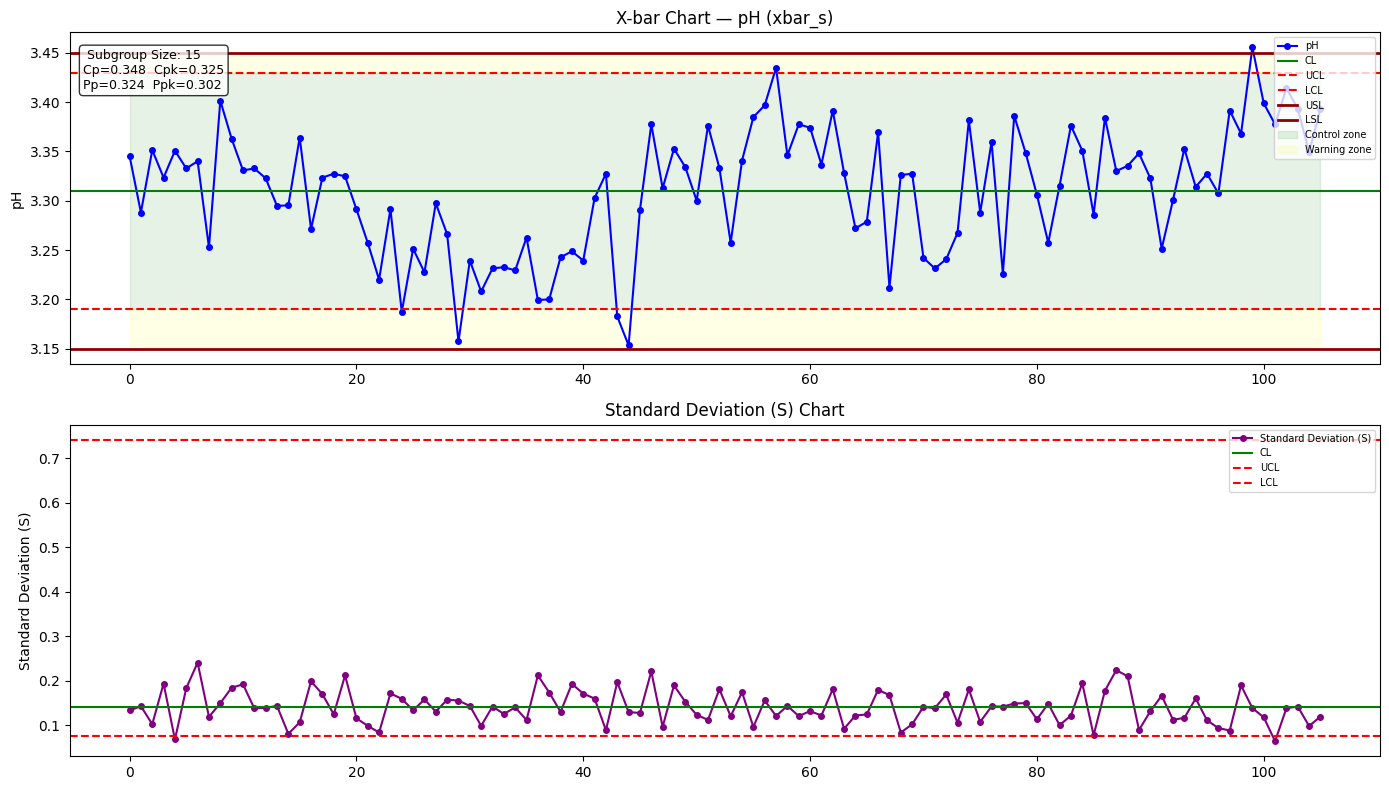

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
x = range(len(xbar))
x2 = range(len(sub_stat))

# --- X-bar / Individuals Chart ---
ax1.plot(x, xbar, marker='o', color='blue', markersize=4, label=column)
ax1.axhline(xbar_bar, color='green', linewidth=1.5, label='CL')
ax1.axhline(UCL_xbar, color='red', linewidth=1.5, linestyle='--', label='UCL')
ax1.axhline(LCL_xbar, color='red', linewidth=1.5, linestyle='--', label='LCL')
ax1.axhline(USL, color='darkred', linewidth=2, linestyle='-', label='USL')
ax1.axhline(LSL, color='darkred', linewidth=2, linestyle='-', label='LSL')

# Color zones
ax1.fill_between(x, LCL_xbar, UCL_xbar, alpha=0.1, color='green', label='Control zone')
ax1.fill_between(x, UCL_xbar, USL, alpha=0.1, color='yellow', label='Warning zone')
ax1.fill_between(x, LSL, LCL_xbar, alpha=0.1, color='yellow')

ax1.set_title(f'X-bar Chart — {column} ({chart_type})')
ax1.set_ylabel(column)
ax1.legend(loc='upper right', fontsize=7)

# --- R / S / MR Chart ---
ax2.plot(x2, sub_stat, marker='o', color='purple', markersize=4, label=sub_label)
ax2.axhline(np.nanmean(sub_stat), color='green', linewidth=1.5, label='CL')
ax2.axhline(UCL_R, color='red', linewidth=1.5, linestyle='--', label='UCL')
ax2.axhline(LCL_R, color='red', linewidth=1.5, linestyle='--', label='LCL')

ax2.set_title(f'{sub_label} Chart')
ax2.set_ylabel(sub_label)
ax2.legend(loc='upper right', fontsize=7)

stats_text = f" Subgroup Size: {subgroup_size}\nCp={Cp:.3f}  Cpk={Cpk:.3f}\nPp={Pp:.3f}  Ppk={Ppk:.3f}"
ax1.text(0.01, 0.95, stats_text, transform=ax1.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


plt.tight_layout()
plt.show()


### Save SPC Report to Excel

In [ ]:
import openpyxl
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image as XLImage
import io

# --- Save matplotlib figure to a bytes buffer ---
buf = io.BytesIO() # Create an in-memory bytes buffer
fig.savefig(buf, format='png', dpi=150, bbox_inches='tight') # Save the figure to the buffer
buf.seek(0) # Move the cursor to the beginning of the buffer

# --- Build Excel workbook ---
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "SPC Report"

# Stats summary block
stats = [
    ["Column", column],
    ["Chart Type", chart_type],
    ["Subgroup Size", subgroup_size],
    ["CL (X-bar)", round(xbar_bar, 4)],
    ["UCL", round(UCL_xbar, 4)],
    ["LCL", round(LCL_xbar, 4)],
    ["USL", USL],
    ["LSL", LSL],
    ["Sigma (ST)", round(sigma_st, 4)],
    ["Sigma (LT)", round(sigma_lt, 4)],
    ["Cp",  round(Cp, 4)],
    ["Cpk", round(Cpk, 4)],
    ["Pp",  round(Pp, 4)],
    ["Ppk", round(Ppk, 4)],
]

for row in stats:
    ws.append(row)

# Subgroup data sheet
ws2 = wb.create_sheet("Data")
ws2.append(["Subgroup", "X-bar", sub_label])
for i, (xb, ss) in enumerate(zip(xbar, sub_stat)):
    ws2.append([i + 1, round(float(xb), 4), round(float(ss), 4)])

# Insert chart image — starts at row 16 of the stats sheet
img = XLImage(buf)
img.anchor = "D1"
ws.add_image(img)

# Save
output_path = r'C:\Users\NidhinD\OneDrive - PBC Linear\Documents\nidhin.dev\Python Files\python.py\py.datasets\spc_report.xlsx'
wb.save(output_path)
print(f"Saved: {output_path}")


Saved: C:\Users\NidhinD\OneDrive - PBC Linear\Documents\nidhin.dev\Python Files\python.py\py.datasets\spc_report.xlsx
